In [1]:
import shap
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from rdkit.Chem import MolFromSmiles, rdFingerprintGenerator
from collections import defaultdict


import sys
sys.path.append('../')
import FragShapley

In [2]:
regression_datasets = ['O43570_Kd', 'P00915_Kd'][:1]
n_cv = 2
n_hyperopt = 2

n_explain = 5

fpSize = 2048
radius = 2

expected_value = 'empty'

random_state = 42

rfr_parameter_grid = {'n_estimators': [50]}

results_folder = 'fingerprint_regression/'

In [3]:
rows_performance = []
df_expl = pd.DataFrame()

for regression_dataset in regression_datasets:
    print(f'On regression dataset: {regression_dataset}')

    # load dataset
    df = pd.read_csv(f'../0_datasets/regression/{regression_dataset}.csv')

    # cross validation
    cv = KFold(n_splits=n_cv,
               shuffle=True,
               random_state=random_state,
               )
    
    for split, (train_index, test_index) in enumerate(cv.split(df)):
        print(f'\tIn split: {split}')

        # split data and get fingerprints
        smiles_train = df.nonstereo_aromatic_smiles.iloc[train_index].to_list()
        smiles_test = df.nonstereo_aromatic_smiles.iloc[test_index].to_list()
        y_train, y_test = df.pPot_mean.iloc[train_index].to_list(), df.pPot_mean.iloc[test_index].to_list()

        mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=radius,
                                                           fpSize=fpSize,
                                                           )
        fps_train = np.stack([mfpgen.GetFingerprintAsNumPy(MolFromSmiles(sm)) for sm in smiles_train])
        fps_test = np.stack([mfpgen.GetFingerprintAsNumPy(MolFromSmiles(sm)) for sm in smiles_test])

        # set up hyper parameter optimization using GridSearchCV
        rfr = RandomForestRegressor(random_state=random_state)
        inner_cv = KFold(n_splits=n_hyperopt,
                         shuffle=True,
                         random_state=random_state,
                         )
        gridCV = GridSearchCV(estimator=rfr,
                             param_grid=rfr_parameter_grid,
                             scoring='neg_root_mean_squared_error', # use RMSE here
                             refit=True, # we want to use the best estimator afterwards
                             )
        gridCV.fit(X=fps_train,
                   y=y_train)
        
        best_regr = gridCV.best_estimator_
        y_pred = best_regr.predict(fps_test)
        rows_performance.append({'dataset': regression_dataset,
                                 'split': split,
                                 'best_params': gridCV.best_params_,
                                 'train_index': train_index,
                                 'test_index': test_index,
                                 'y_test': y_test,
                                 'y_pred': y_pred,
                                 })

        # now the whole explanation part
        smiles_explain = smiles_test[:n_explain]

        # run FragShapley
        frag_explainer = FragShapley.FragmentExplainer(model = best_regr,
                                                          fingerprint_generator=mfpgen,
                                                          fragmentation_method='BRICS',
                                                          expected_value=expected_value)
        ev_frag = frag_explainer.expected_value
        # results_dicts, atom_id_to_bits, frag_to_atom_ids = frag_explainer.explain(smiles_explain)
        results_dicts, frag_to_atom_ids, atom_id_to_bits = frag_explainer.explain(smiles_explain, return_atom_id_to_bits=True)

        # run shap TreeExplainer
        shap_explainer = shap.TreeExplainer(model=best_regr,
                                            data=fps_train,
                                            model_output='raw',
                                            feature_perturbation='interventional',
                                            )
        shap_expl = shap_explainer.shap_values(fps_test[:n_explain])
        shap_expl = [i for i in shap_expl]
        shap_ev = shap_explainer.expected_value

        results = {'dataset': regression_dataset,
                   'split': split,
                   'smiles': smiles_explain,
                   'y_true': y_test[:n_explain],
                   'y_pred': y_pred[:n_explain],
                   'fragExplainer_result': results_dicts,
                   'fragExplainer_expected_value': [ev_frag for _ in smiles_explain],
                   'shap_result': shap_expl,
                   'shap_expected_value': [shap_ev for _ in smiles_explain],
                   'atom_id_to_bits': atom_id_to_bits,
                   'frag_to_atom_ids': frag_to_atom_ids,
                   }
        df_expl_inner = pd.DataFrame(results)
        df_expl = pd.concat((df_expl, df_expl_inner))

df_performance = pd.DataFrame(rows_performance)
df_performance.to_pickle(results_folder + 'df_performance.pkl')
df_expl.to_pickle(results_folder + 'df_explanation.pkl')

On regression dataset: O43570_Kd
	In split: 0
	In split: 1


# Performance Analysis

In [4]:
df_performance = pd.read_pickle(results_folder + 'df_performance.pkl')
df_expl = pd.read_pickle(results_folder + 'df_explanation.pkl')

In [5]:
import seaborn as sns
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

df_performance['RMSE'] = df_performance.apply(lambda x: root_mean_squared_error(y_true=x.y_test, y_pred=x.y_pred), axis=1)
df_performance['MAE'] = df_performance.apply(lambda x: mean_absolute_error(y_true=x.y_test, y_pred=x.y_pred), axis=1)
df_performance['R^2'] = df_performance.apply(lambda x: r2_score(y_true=x.y_test, y_pred=x.y_pred), axis=1)

<Axes: xlabel='metric', ylabel='value'>

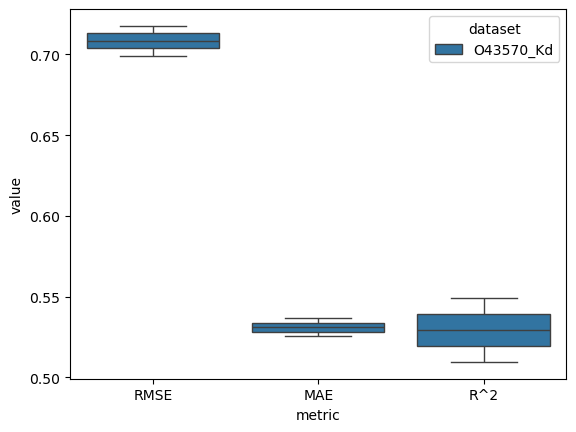

In [6]:
df_perf_molten = pd.melt(frame=df_performance,
                         id_vars=['dataset', 'split'],
                         value_vars=['RMSE', 'MAE', 'R^2'],
                         value_name='value',
                         var_name='metric')
sns.boxplot(df_perf_molten,
            x='metric',
            y='value',
            hue='dataset',
)

# Explanation Analysis

## Sanity Checks

In [7]:
df_expl = pd.read_pickle(results_folder + 'df_explanation.pkl')

In [8]:
def check_fragment_values(fragment_dict, expected_value, y_pred):
    return np.allclose((sum(fragment_dict.values()) + expected_value), y_pred)

def check_shap_values(shap_values, expected_value, y_pred):
    return np.allclose(shap_values.sum() + expected_value, y_pred)

In [9]:
df_expl['check_fragExplainer_output'] = df_expl.apply(lambda x: check_fragment_values(x.fragExplainer_result, x.fragExplainer_expected_value, x.y_pred), axis=1)
df_expl['check_fragExplainer_output'].value_counts()

check_fragExplainer_output
True    10
Name: count, dtype: int64

In [10]:
df_expl['check_shap_output'] = df_expl.apply(lambda x: check_shap_values(x.shap_result, x.shap_expected_value, x.y_pred), axis=1)
df_expl['check_shap_output'].value_counts()

check_shap_output
True    10
Name: count, dtype: int64

In [11]:
df_expl.head()

,dataset,split,smiles,y_true,y_pred,fragExplainer_result,fragExplainer_expected_value,shap_result,shap_expected_value,atom_id_to_bits,frag_to_atom_ids,check_fragExplainer_output,check_shap_output
0,O43570_Kd,0,Brc1ccc(-c2nn(-c3ccccc3)cc2-c2nc3ccccc3[nH]2)cc1,7.137272,7.792899,"{0: 0.24155281243190269, 1: 1.4230175552095006...",5.896076,"[0.0, 0.0006325605711799653, 6.756729737389833...",7.465602,"{23: [119, 535, 1380], 24: [180, 1114, 1745], ...","{0: [0, 1, 2, 3, 4, 25, 26], 1: [5, 6, 7, 14, ...",True,True
1,O43570_Kd,0,C#CCNC(=O)c1ccc(S(N)(=O)=O)cc1,9.000000,7.866565,"{0: 0.0025613671432289722, 1: 0.04390131753969...",5.896076,"[0.0, 0.00357870292464213, 0.00025748265870788...",7.465602,"{2: [80, 1057, 1197], 3: [197, 348, 1152], 4: ...","{0: [0, 1, 2], 1: [3], 2: [4, 5], 3: [6, 7, 8,...",True,True
2,O43570_Kd,0,C#CCNc1ccc(S(N)(=O)=O)cc1,6.105795,7.752016,"{0: 0.12687281914709794, 1: -0.056727812201463...",5.896076,"[0.0, 0.0023397993986145594, 0.000212278875696...",7.465602,"{4: [62, 191, 1380], 2: [80, 1057, 1756], 7: [...","{0: [0, 1, 2], 1: [3], 2: [4, 5, 6, 7, 8, 9, 1...",True,True
3,O43570_Kd,0,C#CCOP(=O)(Oc1ccc(S(N)(=O)=O)cc1)c1ccccc1,7.547826,7.101444,"{0: 0.06586241715723107, 1: 0.0703626157316055...",5.896076,"[0.0, 0.0013094330118474317, 0.000156792765264...",7.465602,"{6: [24, 335, 695], 4: [44, 192, 1586], 2: [80...","{0: [0, 1, 2], 1: [3, 4, 5, 6, 17, 18, 19, 20,...",True,True
4,O43570_Kd,0,C#CCOc1c(C=NCc2ccc(S(N)(=O)=O)cc2)cccc1OC,6.180917,6.234959,"{0: -0.2170342866788857, 1: -0.008155741336156...",5.896076,"[0.0, 0.0016433753792080097, 0.000152460293265...",7.465602,"{2: [80, 1623, 1918], 8: [80, 372, 1435], 23: ...","{0: [0, 1, 2], 1: [3], 2: [4, 5, 6, 7, 8, 19, ...",True,True


## Turn SHAP results into fragment results

In [12]:
row = df_expl.iloc[0]

shap_values = row.shap_result
shap_ev = row.shap_expected_value
atom_id_to_bits = row.atom_id_to_bits
frag_to_atom_ids = row.frag_to_atom_ids
y_pred = row.y_pred

In [13]:
def convert_shap_to_fragments_and_absent(shap_values, atom_id_to_bits, frag_to_atom_ids):
    # get number of bit collisions
    bit_collisions = defaultdict(int)
    for values in atom_id_to_bits.values():
        for v in values:
            bit_collisions[v] += 1

    res = defaultdict(int)
    for frag_id, atom_ids in frag_to_atom_ids.items():
        for atom_id in atom_ids:
            for bit in atom_id_to_bits[atom_id]:
                res[frag_id] += shap_values[bit] / bit_collisions[bit]
    
    # get contribution from absent bit_collisions
    present_bits = list(set(bit_collisions.keys()))
    absent_bits = list(set(range(shap_values.shape[0])).difference(set(present_bits)))
    
    return res, shap_values[absent_bits].sum()

In [14]:
res_old, absent_old = convert_shap_to_fragments_and_absent(shap_values, atom_id_to_bits, frag_to_atom_ids)

In [15]:
def convert_shap_to_atoms_and_absent(shap_values, atom_id_to_bits):
    bit_collisions = defaultdict(int)
    for values in atom_id_to_bits.values():
        for v in values:
            bit_collisions[v] += 1

    res = defaultdict(int)
    for atom_id in list(atom_id_to_bits.keys()):
        for bit in atom_id_to_bits[atom_id]:
            res[atom_id] += shap_values[bit] / bit_collisions[bit]
    
    # get contribution from absent bit_collisions
    present_bits = list(set(bit_collisions.keys()))
    absent_bits = list(set(range(shap_values.shape[0])).difference(set(present_bits)))
    
    return res, shap_values[absent_bits].sum()

In [16]:
res, absent = convert_shap_to_atoms_and_absent(shap_values, atom_id_to_bits=atom_id_to_bits)

In [17]:
df_expl[['shap_fragments', 'shap_contribution_absent']] = df_expl.apply(lambda x: convert_shap_to_fragments_and_absent(x.shap_result,
                                                                                                                       x.atom_id_to_bits,
                                                                                                                       x.frag_to_atom_ids,
                                                                                                                       ),
                                                                                                                       axis=1,
                                                                                                                       result_type='expand')

In [18]:
df_expl[['shap_atoms', 'shap_contribution_absent_2']] = df_expl.apply(lambda x: convert_shap_to_atoms_and_absent(x.shap_result,
                                                                                                                 x.atom_id_to_bits,
                                                                                                                ),
                                                                                                                axis=1,
                                                                                                                result_type='expand')

In [19]:
# take a look at the correlation now
idx = 0
row = df_expl.iloc[idx]

res_frag = row.fragExplainer_result
res_shap = row.shap_fragments

sorted_res_frag = {k:res_frag[k] for k in sorted(res_frag.keys())}
sorted_res_shap = {k:res_shap[k] for k in sorted(res_shap.keys())}

In [20]:
def sort_dictionaries(dictionary):
    return {k:dictionary[k] for k in sorted(dictionary.keys())}

In [21]:
df_expl['fragExplainer_result'] = df_expl.fragExplainer_result.apply(sort_dictionaries)
df_expl['shap_fragments'] = df_expl.shap_fragments.apply(sort_dictionaries)

In [22]:
values_frag = []
values_shap = []

for idx_row, row in df_expl.iterrows():
    values_frag += list(row.fragExplainer_result.values())
    values_shap += list(row.shap_fragments.values())

<Axes: >

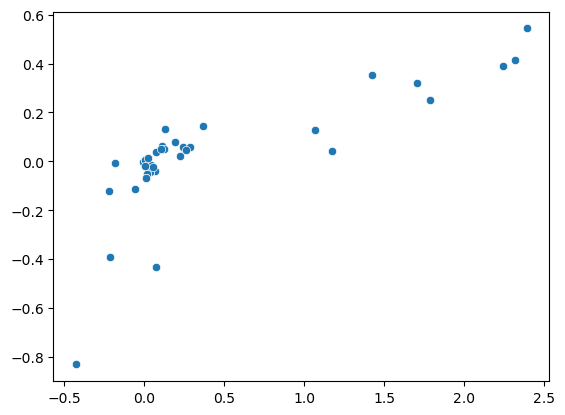

In [23]:
sns.scatterplot(x=values_frag,
                y=values_shap)

In [24]:
from rdkit.Chem import Draw
from IPython.display import SVG

def visualize_contributions(smiles, contributions, scale=0.5):
    chargeRadii = {}
    chargeColors = {}
    highlightAtoms = []
    for i,chg in enumerate(contributions):
        # quantize and scale the charge so that we can use it to scale the highlight radii
        #chg = (10*chg//1)/10
        if abs(chg)>1e-4:
            chargeRadii[i] = abs(chg) * scale
            highlightAtoms.append(i)
            if chg>0:
                chargeColors[i] = (1,.5,.5)
            else:
                chargeColors[i] = (.5,.5,1)

    d2d = Draw.MolDraw2DSVG(550,350)
    dopts = d2d.drawOptions()
    dopts.useBWAtomPalette()
    # we need to set the highlights to be circles or we'll end up with ovals
    # that fit around the atomic symbol
    dopts.atomHighlightsAreCircles = True

    # we need to provide highlightBonds=[] here to avoid having the bonds between highlighted atoms highlighted:
    d2d.DrawMolecule(MolFromSmiles(smiles),
                    highlightAtoms=highlightAtoms,
                    highlightAtomColors=chargeColors,
                    highlightAtomRadii=chargeRadii,
                    highlightBonds=[])
    d2d.FinishDrawing()
    return SVG(d2d.GetDrawingText())

In [25]:
def get_frag_contributions_from_result_dict(smiles, results_dict, frag_to_atom_ids):
    contributions = np.zeros(MolFromSmiles(smiles).GetNumAtoms())
    for frag_id in range(len(results_dict.keys())):
        for atom_id in frag_to_atom_ids[frag_id]:
            contributions[atom_id] = results_dict[frag_id]
    return contributions

In [26]:
def get_atom_contributions_from_result_dict(smiles, results_dict):
    contributions = np.zeros(MolFromSmiles(smiles).GetNumAtoms())
    for atom_id in results_dict.keys():
        contributions[atom_id] = results_dict[atom_id]
    return contributions

In [27]:
row_id = 0
row = df_expl.iloc[row_id]
smiles = row.smiles
shap_contributions_frag = get_frag_contributions_from_result_dict(smiles=smiles, 
                                                                  results_dict=row.shap_fragments,
                                                                  frag_to_atom_ids=row.frag_to_atom_ids)
shap_contributions_atom = get_atom_contributions_from_result_dict(smiles=smiles,
                                                                  results_dict=row.shap_atoms)
frag_contributions_frag = get_frag_contributions_from_result_dict(smiles=smiles, 
                                                                  results_dict=row.fragExplainer_result,
                                                                  frag_to_atom_ids=row.frag_to_atom_ids)

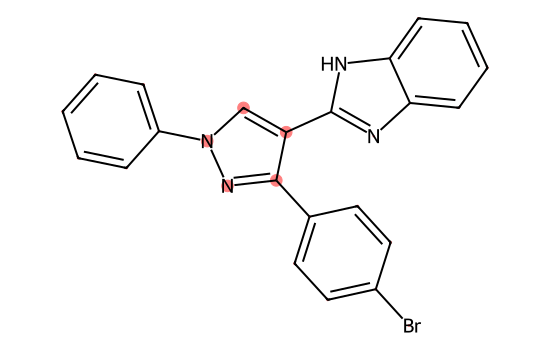

In [28]:
# from SHAP using fragments
# might need to work on using a different scaling here???
visualize_contributions(smiles=smiles,
                        contributions=shap_contributions_frag)

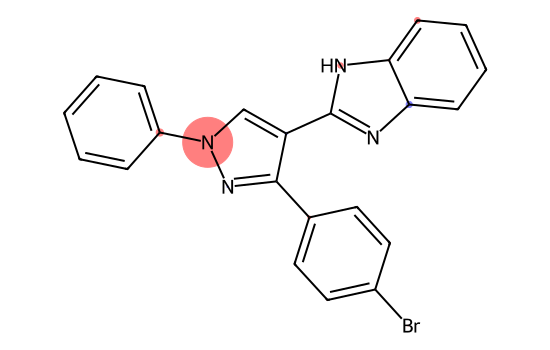

In [29]:
# from SHAP using atoms
visualize_contributions(smiles=smiles,
                        contributions=shap_contributions_atom,
                        scale=2)

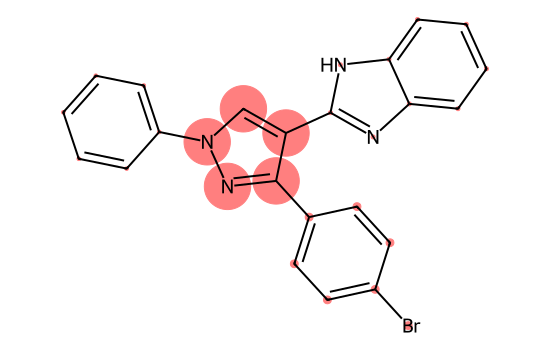

In [30]:
# from fragmentShapley
visualize_contributions(smiles=smiles,
                        contributions=frag_contributions_frag)